In [4]:
import os
import json
import random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.windows import Window
from rasterio.mask import mask

from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from data_loader import (
    load_dem, load_infiltration_map, load_landuse_map, load_manila_mask, load_all_flood_maps, get_raster_stats, print_raster_stats,
    load_all_rainfall_scenarios, get_rainfall_stats, print_rainfall_stats, visualize_raster, visualize_flood_maps_grid, manila_path_shape_load_all_flood_maps
)

RANDOM_SEED = 42
NUM_TRAIN = 15
NUM_TEST = 5
NUM_SCENARIO = 50
PATCH_SIZE = 4
BATCH_SIZE = 1024
NUM_WORKERS = 4     
PIN_MEMORY = False

In [5]:
repo_root = os.getcwd()
gmm_no_manila_path = os.path.join(repo_root, "COP-30m-GMM-ManilaMaskOut")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rs_path = os.path.join(repo_root, "mm_hr_scenarios")

# Loading Data

## Train Data

In [ ]:
print("\n--- Loading DEM ---")
dem_path = os.path.join(gmm_no_manila_path, "by_box", "greater_mm_bbox_dem_cop_noManila_box.tif")
if os.path.exists(dem_path):
    train_dem_data, train_dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(train_dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")

fig1 = visualize_raster(train_dem_data, title="DEM - Manila", cmap='terrain')


# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(gmm_no_manila_path, "by_box", "GM_Infilt_noManila_box.tif")
if os.path.exists(infilt_path):
    train_infilt_data, train_infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(train_infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None
fig2 = visualize_raster(train_infilt_data, title="Infiltration Map", cmap='YlGnBu')

print("\n--- Loading Landuse Map ---")
landuse_path = os.path.join(gmm_no_manila_path, "by_box", "GM_LU_noManila_box.tif")
if os.path.exists(landuse_path):
    train_landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(train_landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None

fig3 = visualize_raster(train_landuse_data, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(gmm_no_manila_path, "by_box")
flood_maps_train, flood_metadata = load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps_train) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps_train)}")
    
    if len(flood_maps_train) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps_train[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

fig4 = visualize_flood_maps_grid(flood_maps=flood_maps_train,scenario_ids=list(range(1, 21)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)




--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -4.9004
Max value:     466.3908
Mean value:    44.9711
Std dev:       71.0011
Valid pixels:  1,273,959 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     3.6847
Mean value:    0.5198
Std dev:       0.9750
Valid pixels:  1,273,959 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    4.8709
Std dev:       2.5478
Valid pixels:  1,273,959 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 11

## Test Data


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -9.1316
Max value:     46.7424
Mean value:    6.1999
Std dev:       5.6200
Valid pixels:  103,041 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     2.7687
Mean value:    0.0126
Std dev:       0.1790
Valid pixels:  103,041 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    5.7113
Std dev:       1.6436
Valid pixels:  103,041 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 1125), dtyp

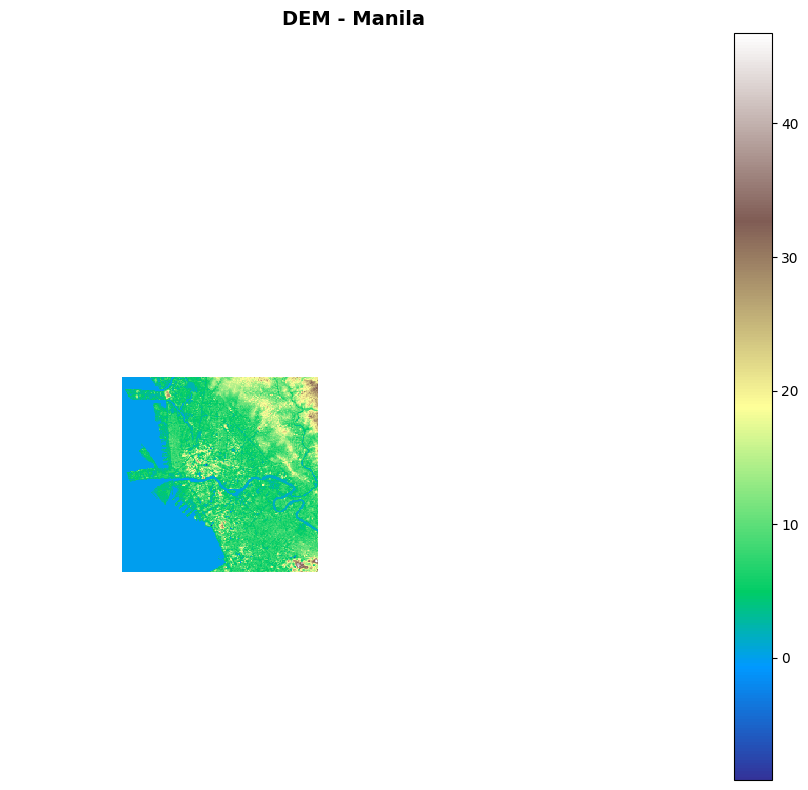

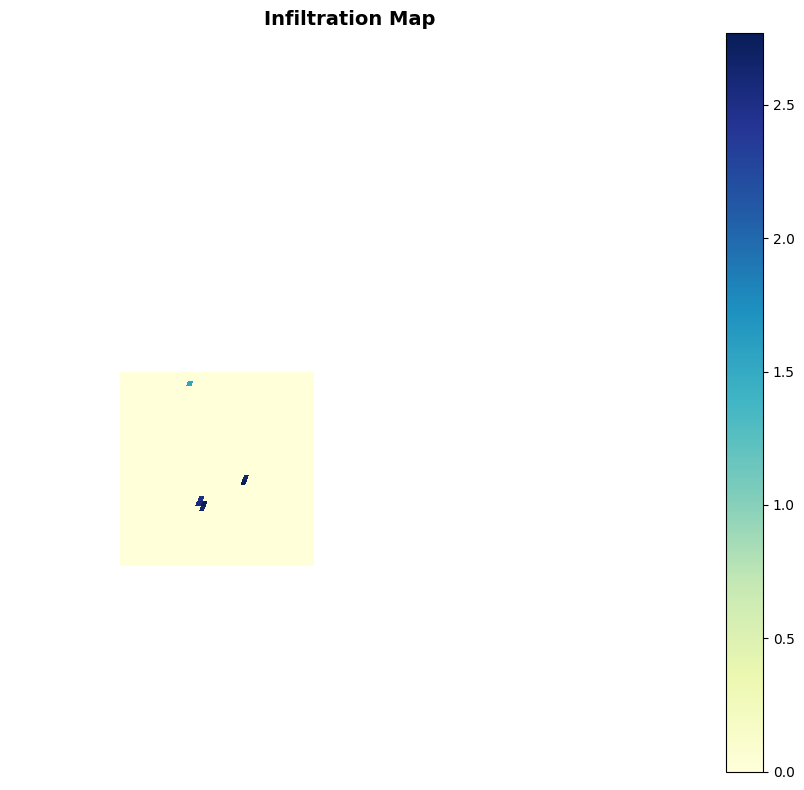

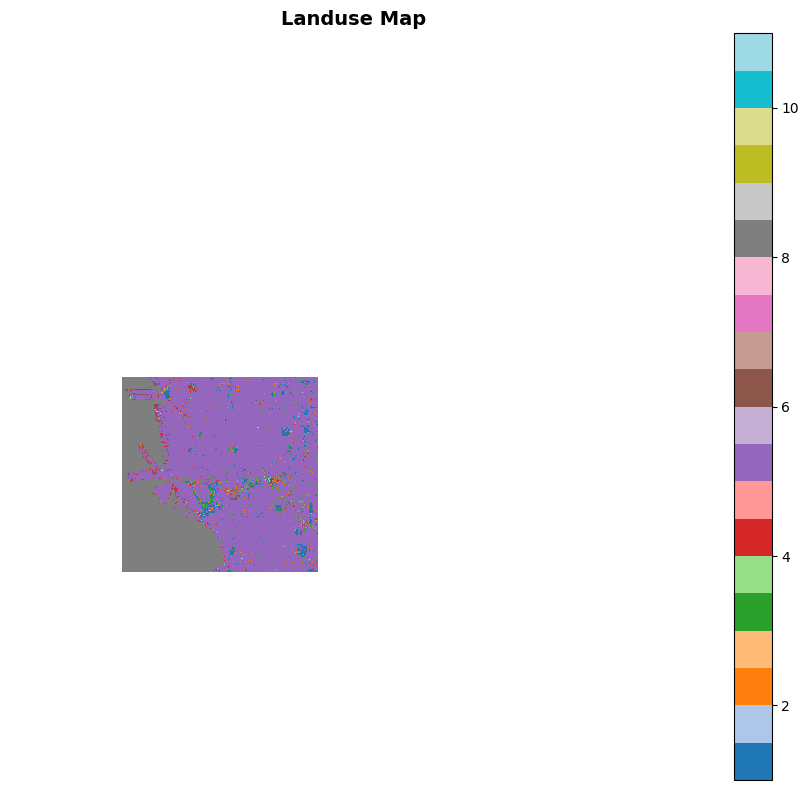

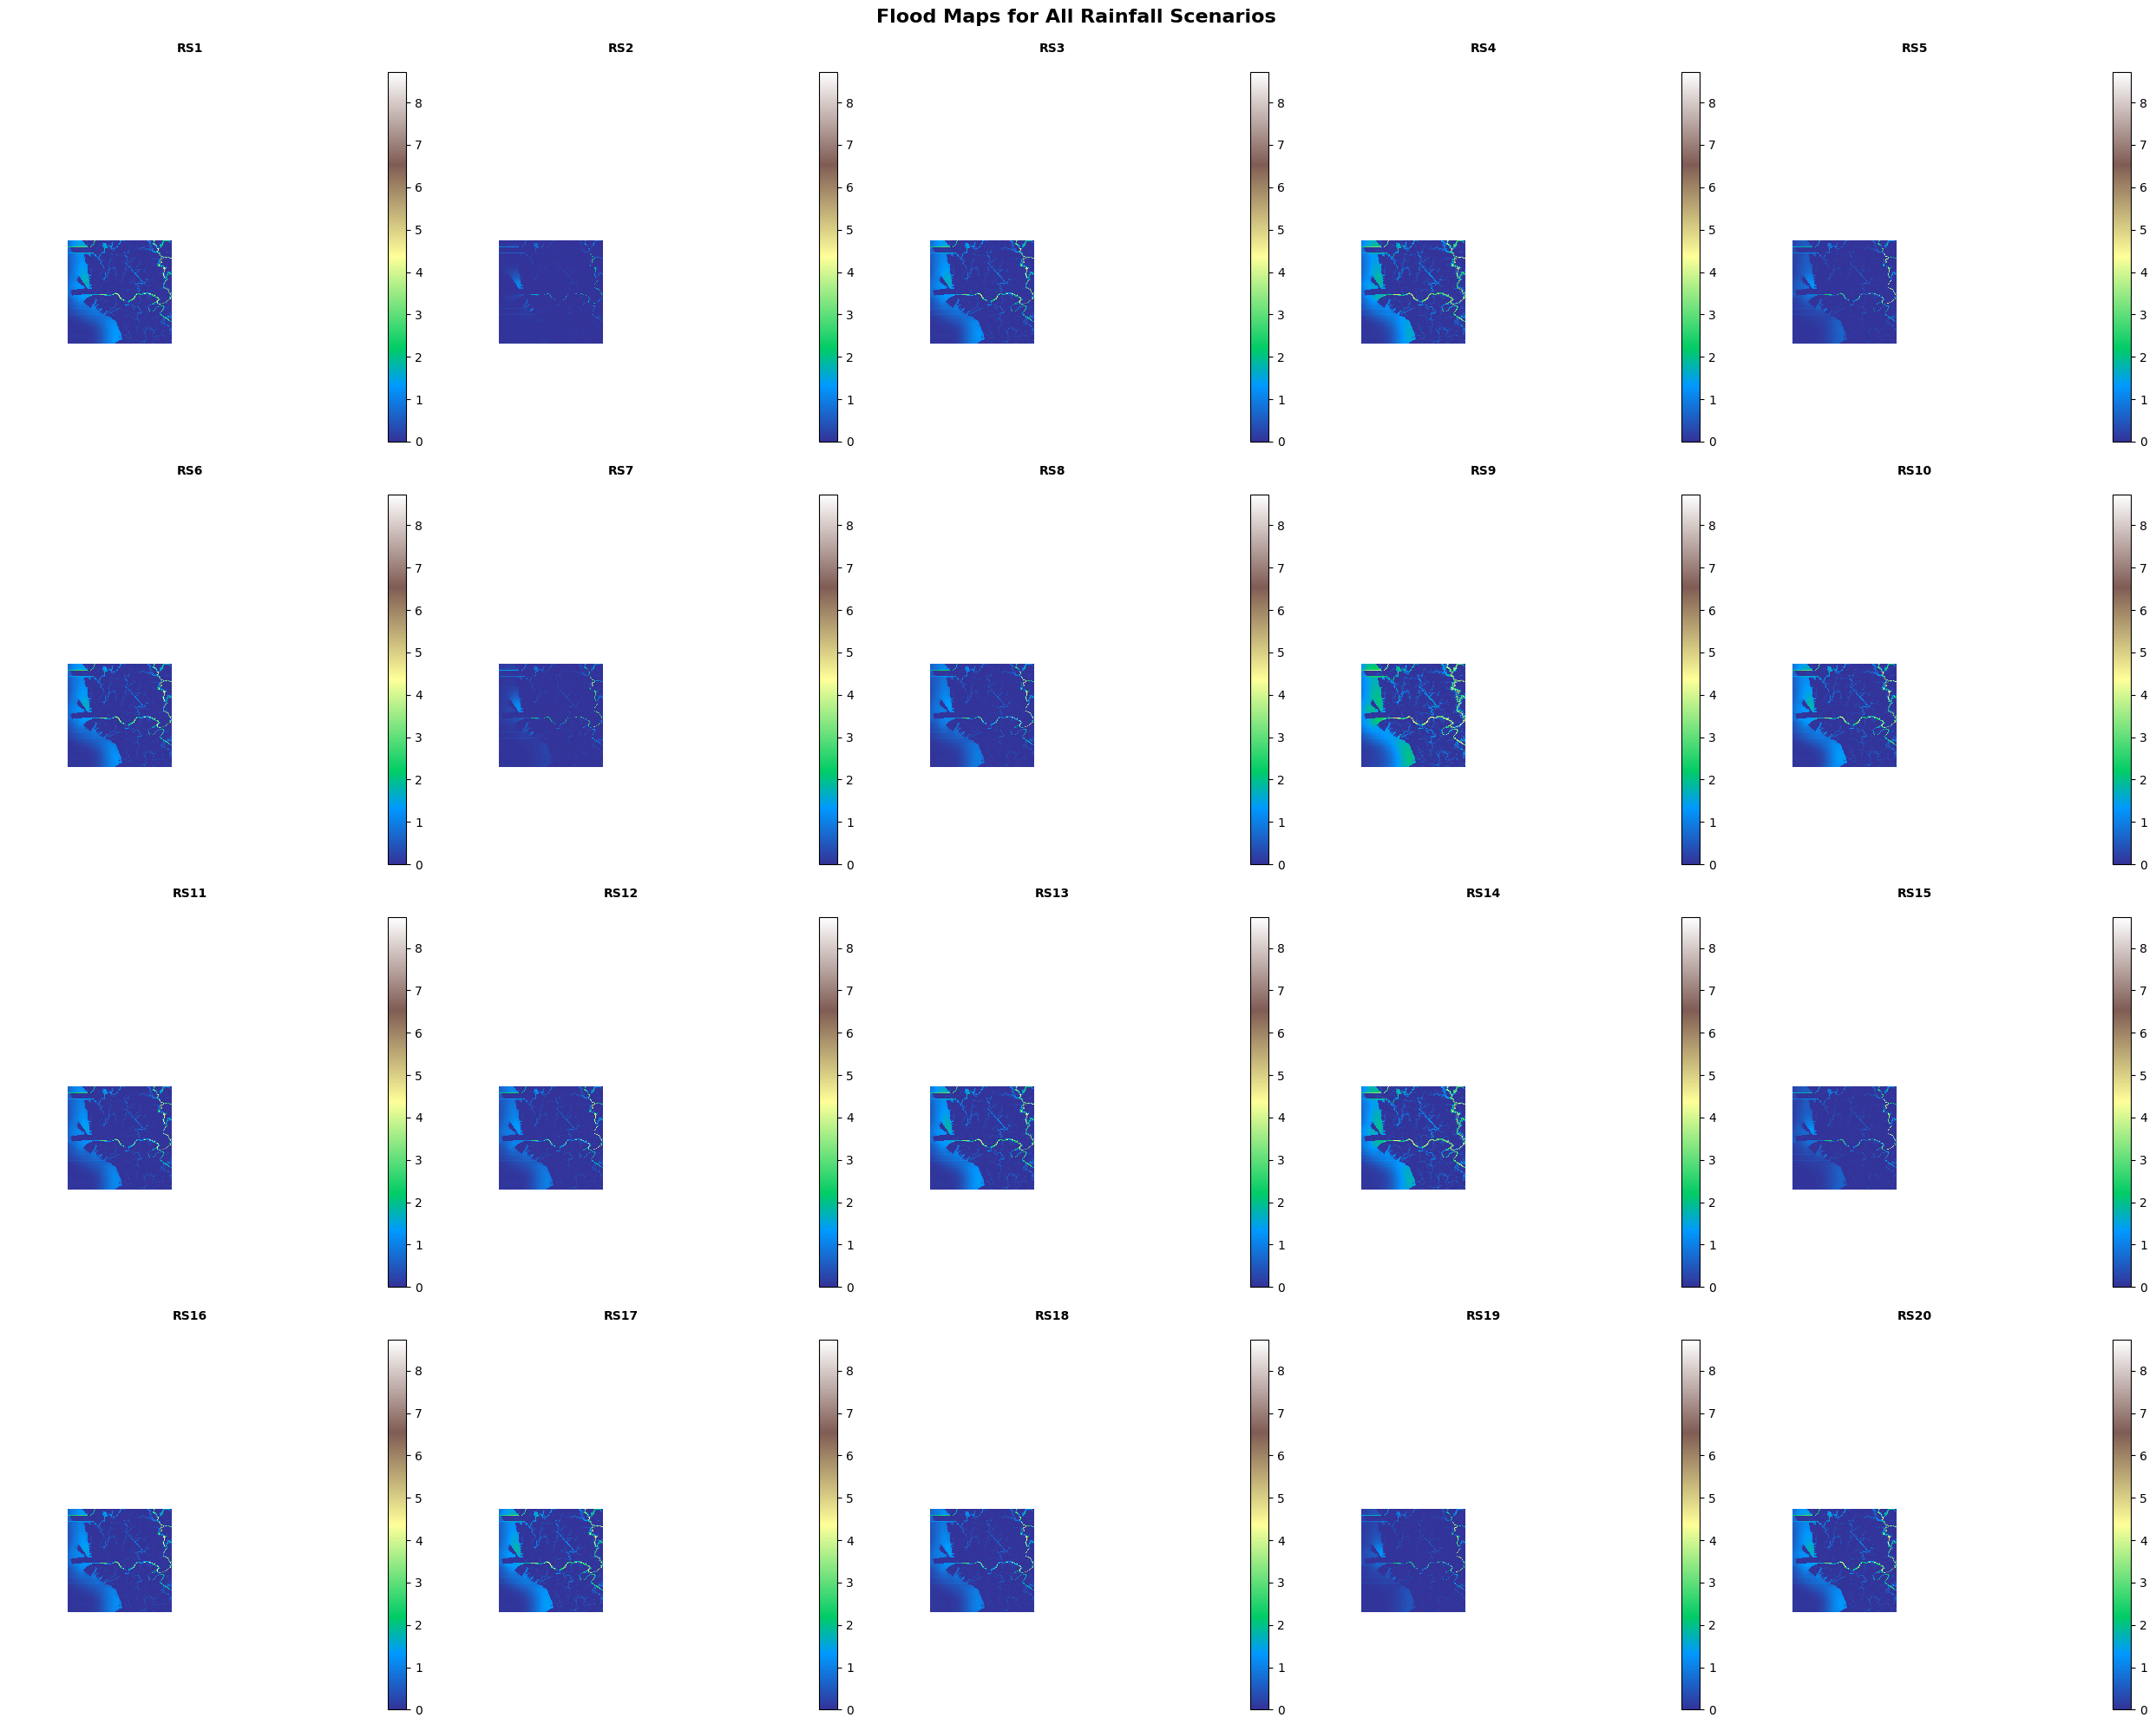

In [ ]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(manila_path, "exp-des-4", "manila_bbox_dem_cop.tif")
if os.path.exists(dem_path):
    dem_data_test, dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(dem_data_test, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")
    dem_data_test = None

fig1 = visualize_raster(dem_data_test, title="DEM - Manila", cmap='terrain')

# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(manila_path, "exp-des-4", "GM_Infilt_Manila_box.tif")
if os.path.exists(infilt_path):
    infilt_data_test, infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(infilt_data_test, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data_test = None
fig2 = visualize_raster(infilt_data_test, title="Infiltration Map", cmap='YlGnBu')

# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path =  os.path.join(manila_path, "exp-des-4", "GM_LU_Manila_box.tif")
if os.path.exists(landuse_path):
    landuse_data_test, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(landuse_data_test, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data_test = None
    
fig3 = visualize_raster(landuse_data_test, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(manila_path, "exp-des-4")
flood_maps_test, flood_metadata = manila_path_shape_load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps_test) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps_test)}")
    
    if len(flood_maps_test) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps_test[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

fig4 = visualize_flood_maps_grid(flood_maps=flood_maps_test,scenario_ids=list(range(1, 21)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)

## Rainfall Scenarios

In [ ]:
print("LOADING RAINFALL SCENARIOS")
# Load rainfall scenarios
rainfall_scenarios = load_all_rainfall_scenarios(rs_path, num_scenarios=20)

if len(rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(rainfall_scenarios)}")
    
    if len(rainfall_scenarios) >= NUM_SCENARIO:
        rain_stats = get_rainfall_stats(rainfall_scenarios[-1], scenario_id=20)
else:
    print("WARNING: No rainfall scenarios loaded!")

print_rainfall_stats(rain_stats)
display(rainfall_scenarios)

LOADING RAINFALL SCENARIOS
Rainfall Scenario 1 loaded: 13 time steps
Rainfall Scenario 2 loaded: 13 time steps
Rainfall Scenario 3 loaded: 13 time steps
Rainfall Scenario 4 loaded: 13 time steps
Rainfall Scenario 5 loaded: 13 time steps
Rainfall Scenario 6 loaded: 13 time steps
Rainfall Scenario 7 loaded: 13 time steps
Rainfall Scenario 8 loaded: 13 time steps
Rainfall Scenario 9 loaded: 13 time steps
Rainfall Scenario 10 loaded: 13 time steps
Rainfall Scenario 11 loaded: 13 time steps
Rainfall Scenario 12 loaded: 13 time steps
Rainfall Scenario 13 loaded: 13 time steps
Rainfall Scenario 14 loaded: 13 time steps
Rainfall Scenario 15 loaded: 13 time steps
Rainfall Scenario 16 loaded: 13 time steps
Rainfall Scenario 17 loaded: 13 time steps
Rainfall Scenario 18 loaded: 13 time steps
Rainfall Scenario 19 loaded: 13 time steps
Rainfall Scenario 20 loaded: 13 time steps

Total rainfall scenarios loaded: 20

Rainfall scenarios successfully loaded: 20

Rainfall Scenario 20 Statistics
Duration

[        hour  intensity_mmhr
 0   0.000000       39.722227
 1   0.083333       82.817226
 2   0.166667       92.492529
 3   0.250000       82.988129
 4   0.333333       64.674010
 5   0.416667       44.595223
 6   0.500000       27.016951
 7   0.583333       13.969586
 8   0.666667        5.793798
 9   0.750000        1.685605
 10  0.833333        0.241450
 11  0.916667        0.003265
 12  1.000000        0.000000,
         hour  intensity_mmhr
 0   0.000000        6.271931
 1   0.083333       13.076404
 2   0.166667       14.604084
 3   0.250000       13.103389
 4   0.333333       10.211686
 5   0.416667        7.041351
 6   0.500000        4.265834
 7   0.583333        2.205724
 8   0.666667        0.914810
 9   0.750000        0.266148
 10  0.833333        0.038124
 11  0.916667        0.000515
 12  1.000000        0.000000,
         hour  intensity_mmhr
 0   0.000000       35.540940
 1   0.083333       74.099623
 2   0.166667       82.756473
 3   0.250000       74.252536
 4   0.3

## Manila Mask


--- Loading Manila Mask ---
Manila mask loaded: shape (389, 358), dtype float32

Statistics for: Mask
Shape:         (389, 358)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0747
Std dev:       0.2629
Valid pixels:  139,262 / 139,262



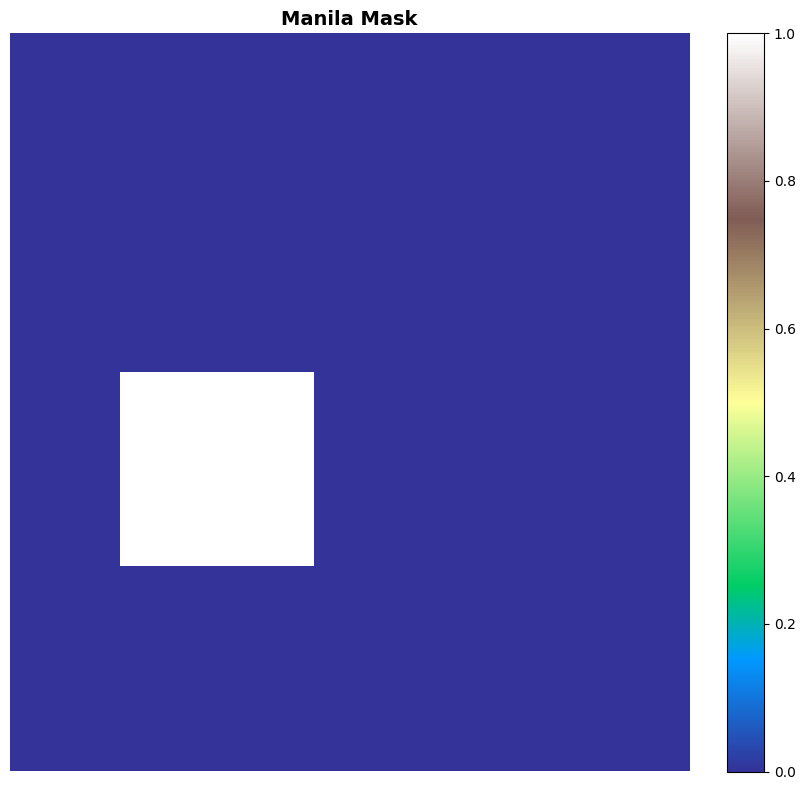

In [ ]:
print("\n--- Loading Manila Mask ---")
mask_path = os.path.join(manila_path, "manila_box_3857.tif")
if os.path.exists(mask_path):
    mask_data, mask_meta = load_manila_mask(mask_path)
    mask_stats = get_raster_stats(mask_data, "Mask")
    print_raster_stats(mask_stats)
else:
    print(f"WARNING: Mask file not found at {mask_path}")

fig1 = visualize_raster(mask_data, title="Manila Mask", cmap='terrain')


In [ ]:
print("\n" + "="*70)
print("PHASE 1.3: MANILA BOX MASK PROCESSING")
print("="*70)

from scipy.ndimage import zoom

# Current mask shape vs required shape
print(f"\nCurrent mask shape: {mask_data.shape}")
# Resize mask to match raster dimensions
target_shape = (1224, 1125)
zoom_factors = (target_shape[0] / mask_data.shape[0], 
                target_shape[1] / mask_data.shape[1])
print(f"\nZoom factors: {zoom_factors}")
mask_resized = zoom(mask_data, zoom_factors, order=0)  # order=0 = nearest neighbor
print(f"Resized mask shape: {mask_resized.shape}")

# Verify values remain binary
unique_values = np.unique(mask_resized)
print(f"Unique values in resized mask: {unique_values}")

# Statistics
mask_resized_stats = get_raster_stats(mask_resized, "Manila Mask (Resized)")
print_raster_stats(mask_resized_stats)
manila_box_mask = mask_resized


PHASE 1.3: MANILA BOX MASK PROCESSING

Current mask shape: (389, 358)

Zoom factors: (3.146529562982005, 3.142458100558659)
Resized mask shape: (1224, 1125)
Unique values in resized mask: [0. 1.]

Statistics for: Manila Mask (Resized)
Shape:         (1224, 1125)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0751
Std dev:       0.2635
Valid pixels:  1,377,000 / 1,377,000



In [ ]:
print("\n  Variables ready for Phase 2:")
print(f"  - train_dem_data (train): {train_dem_data.shape}")
print(f"  - train_infilt_data (train): {train_infilt_data.shape}")
print(f"  - train_landuse_data (train): {train_landuse_data.shape}")
print(f"  - dem_data_test (test): {dem_data_test.shape}")
print(f"  - infilt_data_test (test): {infilt_data_test.shape}")
print(f"  - landuse_data_test (test): {landuse_data_test.shape}")
print(f"  - flood_maps_train (train): {len(flood_maps_train)} maps")
print(f"  - flood_maps_test (test): {len(flood_maps_test)} maps")
print(f"  - manila_box_mask: {manila_box_mask.shape}")
print(f"  - rainfall_scenarios: {len(rainfall_scenarios)} scenarios")


  Variables ready for Phase 2:
  - train_dem_data (train): (1224, 1125)
  - train_infilt_data (train): (1224, 1125)
  - train_landuse_data (train): (1224, 1125)
  - dem_data_test (test): (1224, 1125)
  - infilt_data_test (test): (1224, 1125)
  - landuse_data_test (test): (1224, 1125)
  - flood_maps_train (train): 20 maps
  - flood_maps_test (test): 20 maps
  - manila_box_mask: (1224, 1125)
  - rainfall_scenarios: 20 scenarios


# Spatial Input Preprocessing

In [ ]:
from data_preprocessing import preprocess_spatial_data
import matplotlib.pyplot as plt

preprocessed = preprocess_spatial_data(
    train_dem=train_dem_data,
    train_infilt=train_infilt_data,
    train_landuse=train_landuse_data,
    test_dem=dem_data_test,
    test_infilt=infilt_data_test,
    test_landuse=landuse_data_test,
    mask=manila_box_mask,
    target_shape=(1152, 1152),      
    nodata_method='interpolate', 
    norm_method='minmax'  
)


PHASE 2: SPATIAL INPUT PREPROCESSING

[2.1] Handling NoData Values
----------------------------------------------------------------------
  DEM (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  DEM (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor
  Infiltration (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  Infiltration (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor
  Landuse (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  Landuse (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor

✓ NoData handling complete

[2.2] Resizing to (1152, 1152)
----------------------------------------------------------------------
  Current: (1224, 1125)
  Target: (1152, 1152)
  Train DEM: (1224, 1125) → (1152, 1152) (bilinear)
  Train Infiltration: (1224, 1125) → (1152, 1152) (bilinear)
  Train Landuse: (1224, 1125) → (1152, 1152) (nearest)
  T

In [ ]:
# Extract preprocessed data
train_dem_preprocessed = preprocessed['train']['dem']
train_infilt_preprocessed = preprocessed['train']['infiltration']
train_landuse_preprocessed = preprocessed['train']['landuse']
test_dem_preprocessed = preprocessed['test']['dem']
test_infilt_preprocessed = preprocessed['test']['infiltration']
test_landuse_preprocessed = preprocessed['test']['landuse']
mask_preprocessed = preprocessed['mask']

print(f"  - train_dem_preprocessed: {train_dem_preprocessed.shape}")
print(f"  - train_infilt_preprocessed: {train_infilt_preprocessed.shape}")
print(f"  - train_landuse_preprocessed: {train_landuse_preprocessed.shape}")
print(f"  - test_dem_preprocessed: {test_dem_preprocessed.shape}")
print(f"  - test_infilt_preprocessed: {test_infilt_preprocessed.shape}")
print(f"  - test_landuse_preprocessed: {test_landuse_preprocessed.shape}")
print(f"  - mask_preprocessed: {mask_preprocessed.shape}")
print(f"  - flood_maps_train: {len(flood_maps_train)} scenarios")
print(f"  - flood_maps_test: {len(flood_maps_test)} scenarios")
print(f"  - rainfall_scenarios: {len(rainfall_scenarios)} scenarios")

  - train_dem_preprocessed: (1152, 1152)
  - train_infilt_preprocessed: (1152, 1152)
  - train_landuse_preprocessed: (1152, 1152)
  - test_dem_preprocessed: (1152, 1152)
  - test_infilt_preprocessed: (1152, 1152)
  - test_landuse_preprocessed: (1152, 1152)
  - mask_preprocessed: (1152, 1152)
  - flood_maps_train: 20 scenarios
  - flood_maps_test: 20 scenarios
  - rainfall_scenarios: 20 scenarios


# RAINFALL TEMPORAL SEQUENCE

In [ ]:
from rainfall import preprocess_rainfall_sequences, visualize_rainfall_sequences

# Preprocess rainfall sequences
rainfall_results = preprocess_rainfall_sequences(
    rainfall_scenarios=rainfall_scenarios,
    norm_method='global_max'
)


PHASE 3: RAINFALL TEMPORAL SEQUENCE PREPROCESSING

[3.1] Extracting Rainfall Sequences
----------------------------------------------------------------------
  RS01: 13 timesteps, peak=92.49 mm/hr at t=2
  RS02: 13 timesteps, peak=14.60 mm/hr at t=2
  RS03: 13 timesteps, peak=82.76 mm/hr at t=2
  RS04: 13 timesteps, peak=131.44 mm/hr at t=2
  RS05: 13 timesteps, peak=41.38 mm/hr at t=2
  RS06: 13 timesteps, peak=80.32 mm/hr at t=2
  RS07: 13 timesteps, peak=26.77 mm/hr at t=2
  RS08: 13 timesteps, peak=51.11 mm/hr at t=2
  RS09: 13 timesteps, peak=189.85 mm/hr at t=2
  RS10: 13 timesteps, peak=99.79 mm/hr at t=2
  RS11: 13 timesteps, peak=58.74 mm/hr at t=5
  RS12: 13 timesteps, peak=47.00 mm/hr at t=5
  RS13: 13 timesteps, peak=88.96 mm/hr at t=5
  RS14: 13 timesteps, peak=130.92 mm/hr at t=5
  RS15: 13 timesteps, peak=36.93 mm/hr at t=5
  RS16: 13 timesteps, peak=62.10 mm/hr at t=5
  RS17: 13 timesteps, peak=90.63 mm/hr at t=5
  RS18: 13 timesteps, peak=52.03 mm/hr at t=5
  RS19: 13

Normalized sequences shape: (20, 13)


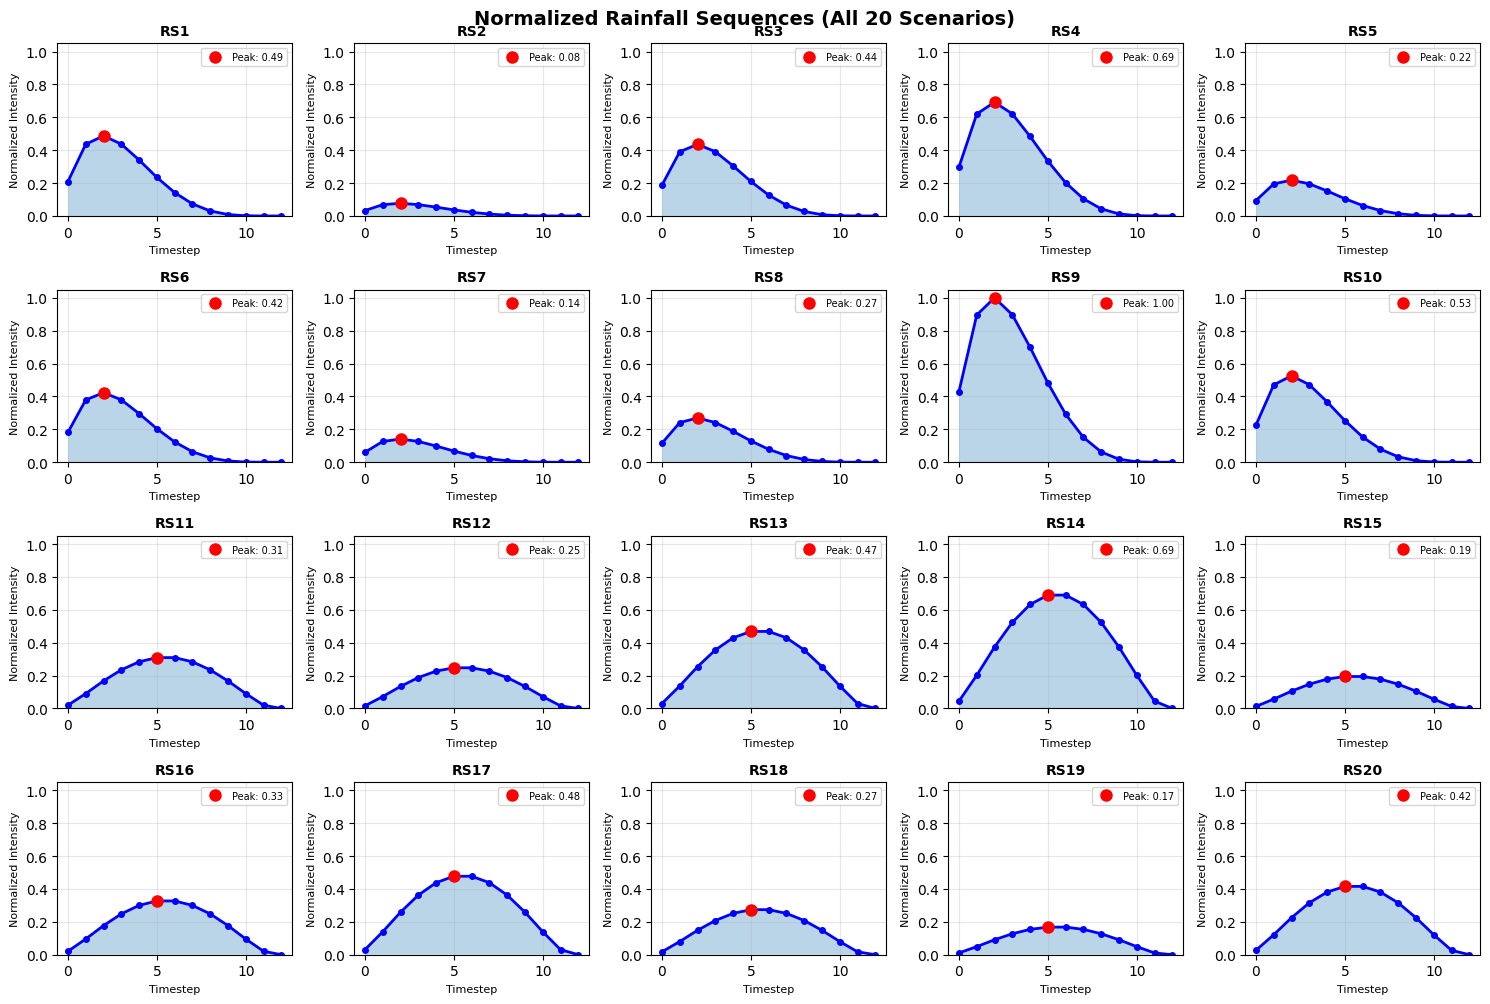

In [ ]:
rainfall_normalized = rainfall_results['sequences']
print(f"Normalized sequences shape: {rainfall_normalized.shape}")

fig = visualize_rainfall_sequences(rainfall_results, num_to_plot=20)

# FLOOD MAP CATEGORIZATION

In [ ]:
from flood_maps import categorize_flood_maps, resize_flood_maps, visualize_categorized_maps  

# Create masks (train = GMM outskirts, test = Manila core)
train_mask = 1 - mask_preprocessed  # Inverse of Manila box
test_mask = mask_preprocessed       # Manila box

flood_maps_train_resized = resize_flood_maps(
    flood_maps=flood_maps_train,
    target_shape=(1152, 1152),
    split_name='Train'
)

flood_maps_test_resized = resize_flood_maps(
    flood_maps=flood_maps_test,
    target_shape=(1152, 1152),
    split_name='Test'
)


Resizing Train Flood Maps
----------------------------------------------------------------------
  Current shape: (1224, 1125)
  Target shape: (1152, 1152)
  Zoom factors: (0.9411764705882353, 1.024)
  Resizing 20 flood maps...
    Progress: 5/20 maps resized
    Progress: 10/20 maps resized
    Progress: 15/20 maps resized
    Progress: 20/20 maps resized
  ✓ All flood maps resized to (1152, 1152)

Resizing Test Flood Maps
----------------------------------------------------------------------
  Current shape: (1224, 1125)
  Target shape: (1152, 1152)
  Zoom factors: (0.9411764705882353, 1.024)
  Resizing 20 flood maps...
    Progress: 5/20 maps resized
    Progress: 10/20 maps resized
    Progress: 15/20 maps resized
    Progress: 20/20 maps resized
  ✓ All flood maps resized to (1152, 1152)


In [ ]:
# Categorize flood maps
categorization_results = categorize_flood_maps(
    train_flood_maps=flood_maps_train_resized,      
    test_flood_maps=flood_maps_test_resized,        
    train_mask=train_mask,
    test_mask=test_mask,
    patch_size=PATCH_SIZE,                          
    categorization_method='majority_vote',   
    class_thresholds=[0.15, 0.24, 0.46, 0.68]
)


PHASE 4: FLOOD MAP CATEGORIZATION

[4.1] Flood Susceptibility Classes
----------------------------------------------------------------------
  Class 0 - No Flood    : [0.00, 0.15) meters
  Class 1 - Light       : [0.15, 0.24) meters
  Class 2 - Moderate    : [0.24, 0.46) meters
  Class 3 - Heavy       : [0.46, 0.68) meters
  Class 4 - Extreme     : [0.68, ∞) meters

[4.2] Patch Configuration
----------------------------------------------------------------------
  Spatial shape: (1152, 1152)
  Patch size: 4×4
  Patches per dimension: 288×288
  Total patches: 82,944
  Categorization method: majority_vote

[4.3] Categorizing Flood Maps
----------------------------------------------------------------------

  Train Set (20 scenarios):
    RS01: 76,553 valid patches, 6,391 NoData
    RS02: 76,553 valid patches, 6,391 NoData
    RS03: 76,553 valid patches, 6,391 NoData
    RS04: 76,553 valid patches, 6,391 NoData
    RS05: 76,553 valid patches, 6,391 NoData
    RS06: 76,553 valid patches, 6

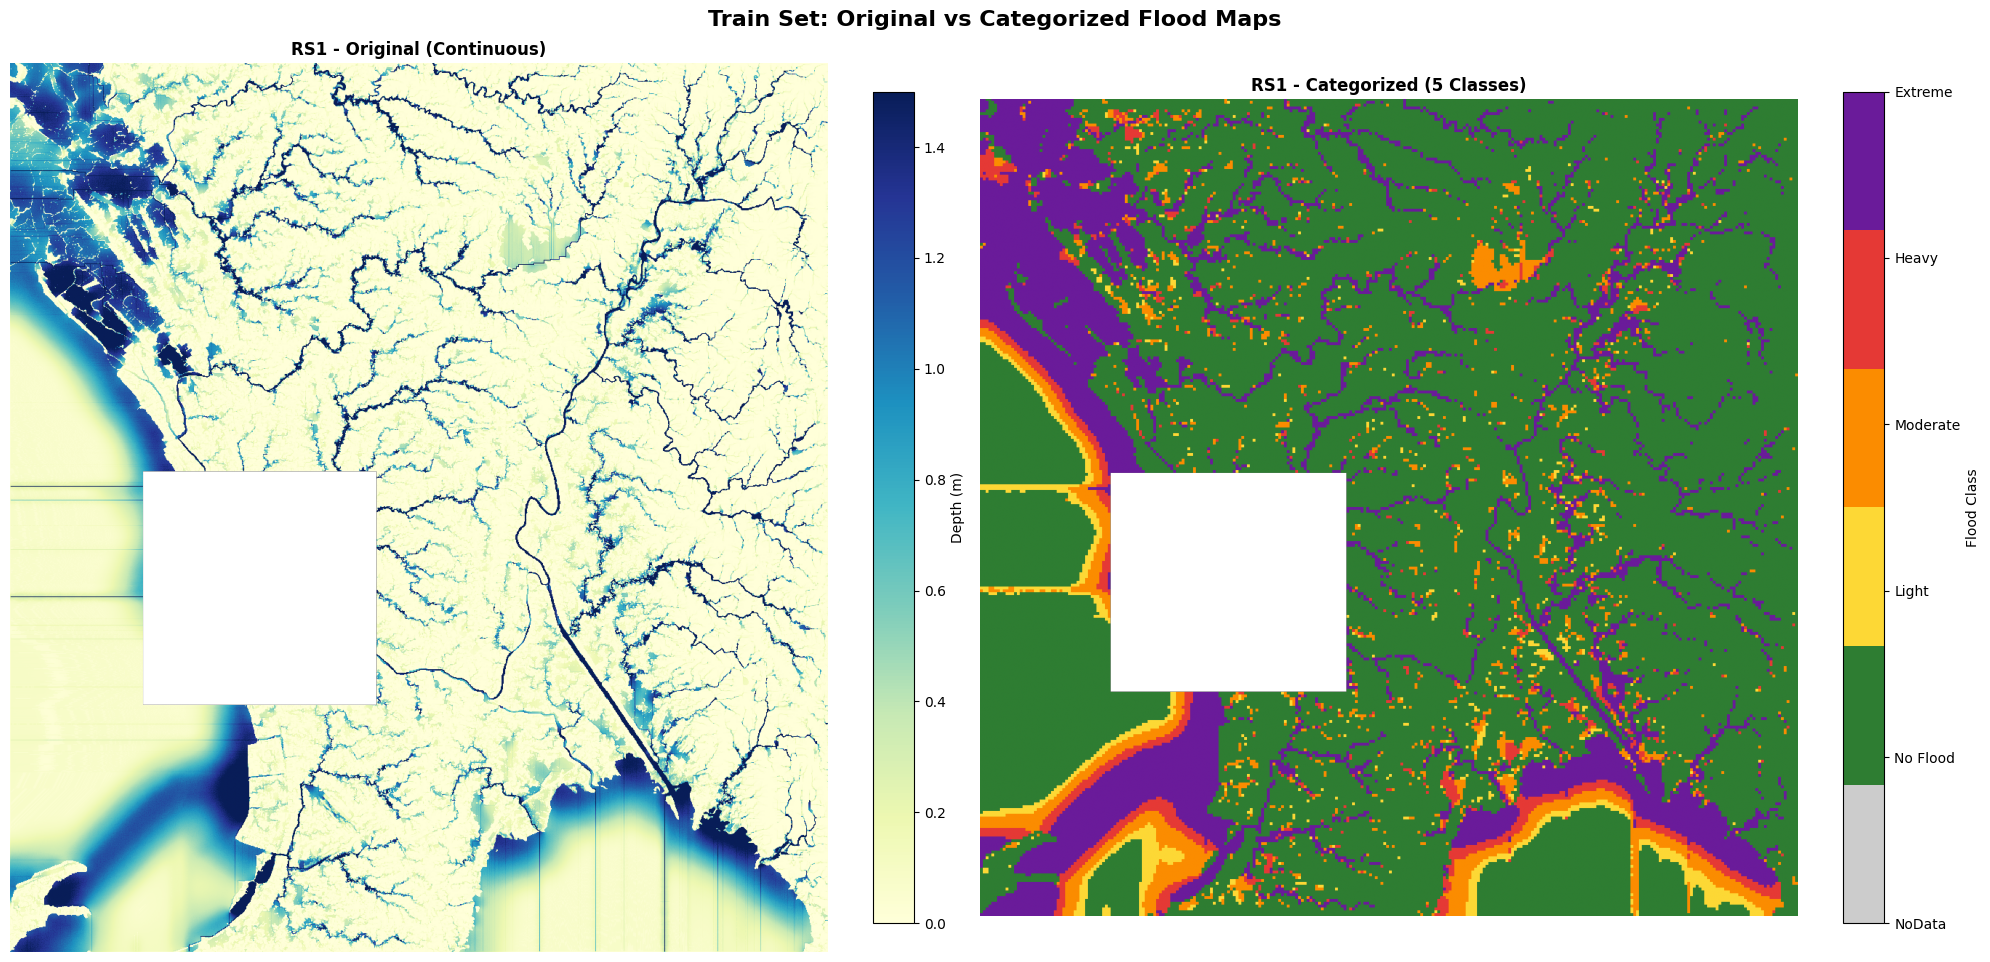

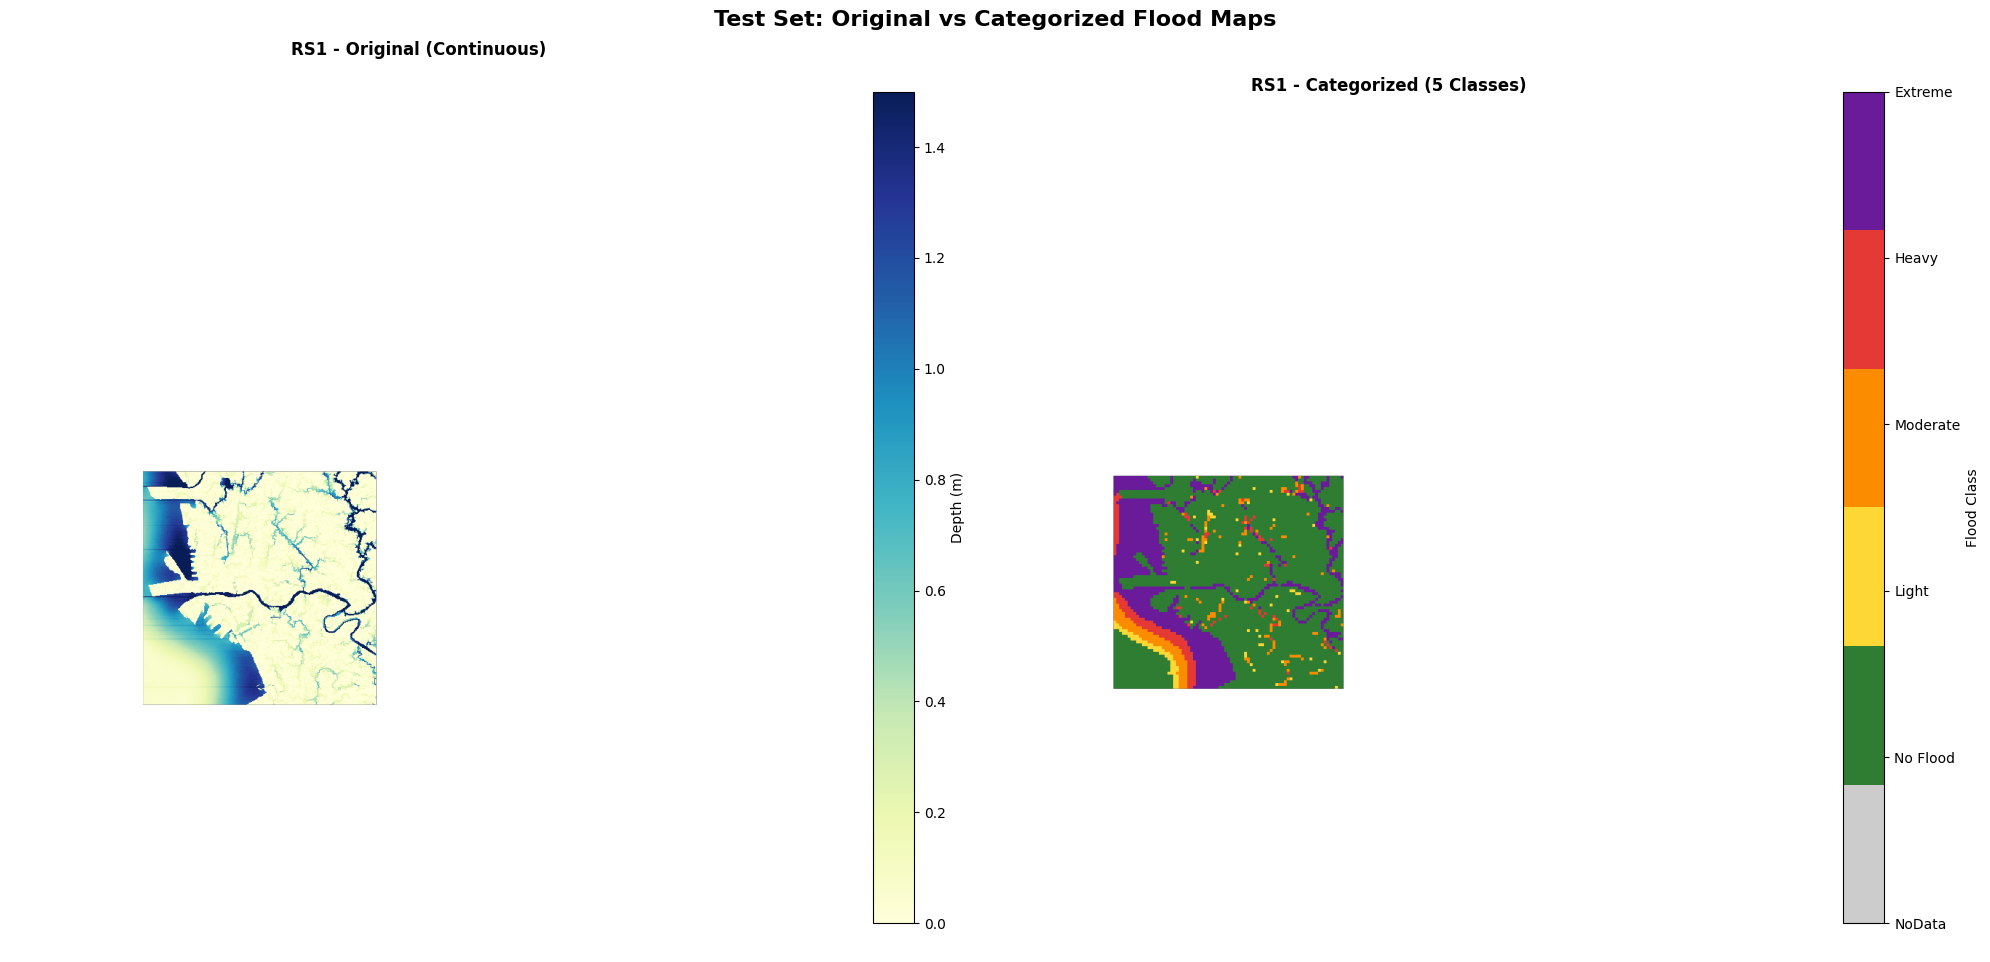

In [ ]:
fig1 = visualize_categorized_maps(
    categorization_results,
    original_flood_maps=flood_maps_train,
    split='train',
    num_scenarios=1
)

fig2 = visualize_categorized_maps(
    categorization_results,
    original_flood_maps=flood_maps_test,
    split='test',
    num_scenarios=1
)


# SPATIAL DATA SPLITTING


SPATIAL DATA SPLITTING

[5.1] Spatial Split Logic
----------------------------------------------------------------------
  Data Structure:
    • Train region: Greater Metro Manila (GMM) - outside Manila box
    • Test region: Metro Manila core - inside Manila box
    • Spatially complementary (non-overlapping)

  Split Strategy:
    • All 20 scenarios used for BOTH regions
    • Training scenarios → GMM patches
    • Testing scenarios → Manila patches

[5.2] Spatial Masks
----------------------------------------------------------------------
  Total pixels: 1,327,104
  GMM region (train): 1,227,417 pixels (92.5%)
  Manila region (test): 99,687 pixels (7.5%)
  Coverage check: 1,327,104 / 1,327,104 ✓

  Patch Alignment:
    Train (GMM): 76,553 patches
    Test (Manila): 6,075 patches

[5.3] Random Scenario Assignment
----------------------------------------------------------------------
  Total scenarios: 20
  Train scenarios: 15 (75%)
  Test scenarios: 5 (25%)
  Random seed: 42

  Trai

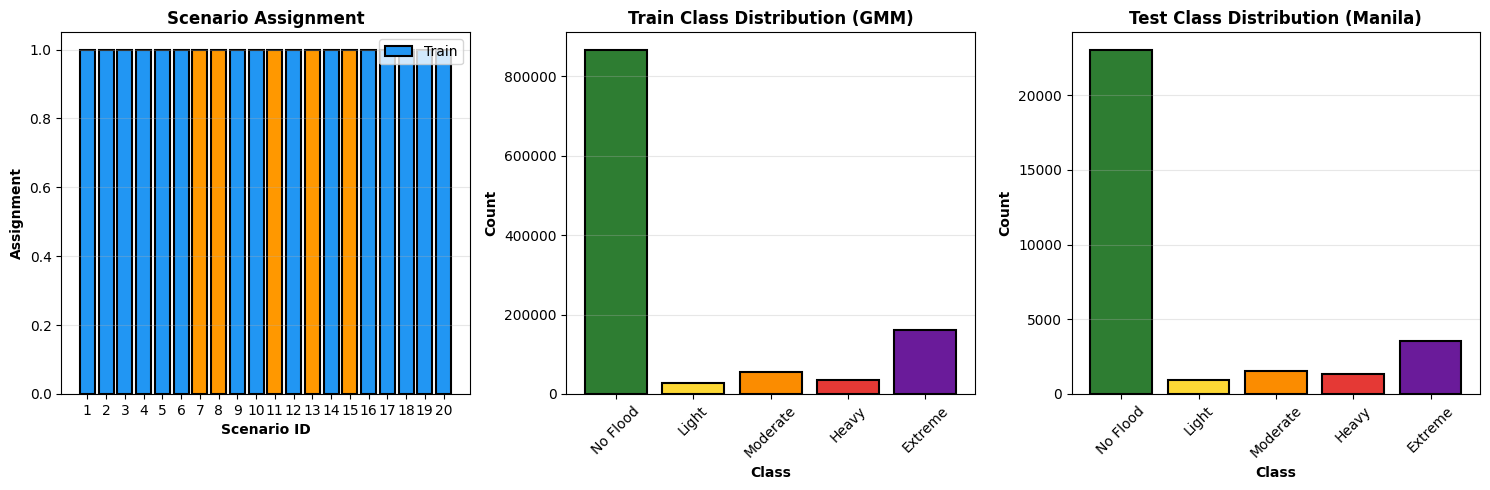


Final Dataset Shapes:
  Train: 1,148,295 samples
  Test: 30,375 samples


In [ ]:
from data_splitting import split_spatial_data, visualize_split_distribution

split_results = split_spatial_data(
    categorization_results=categorization_results,
    preprocessed_spatial=preprocessed, rainfall_results=rainfall_results,
    train_ratio=0.75, random_seed=42, patch_size=PATCH_SIZE)

fig = visualize_split_distribution(split_results)
plt.show()

# Access final data
X_train_spatial = split_results['train']['spatial_patches']      
X_train_rainfall = split_results['train']['rainfall_sequences']   # (N_train, 13)
y_train = split_results['train']['labels']                        # (N_train,)

X_test_spatial = split_results['test']['spatial_patches']         # (N_test, 3, 16, 16)
X_test_rainfall = split_results['test']['rainfall_sequences']     # (N_test, 13)
y_test = split_results['test']['labels']                          # (N_test,)

print(f"\nFinal Dataset Shapes:")
print(f"  Train: {X_train_spatial.shape[0]:,} samples")
print(f"  Test: {X_test_spatial.shape[0]:,} samples")

# PATCH EXTRACTION FOR ViT

In [ ]:
from patchify import extract_vit_patches, get_data_loader_ready

# Extract ViT patches
vit_results = extract_vit_patches(
    split_results=split_results,
    patch_size=PATCH_SIZE
)

train_data, test_data = get_data_loader_ready(vit_results)
X_train_spatial, X_train_rainfall, y_train = train_data
X_test_spatial, X_test_rainfall, y_test = test_data

# Ready for ViT!
print(f"\n Data ready for Vision Transformer!")
print(f"   Train: {len(y_train):,} samples")
print(f"   Test: {len(y_test):,} samples")


PHASE 6: PATCH EXTRACTION FOR ViT

[6.1] Patch Configuration
----------------------------------------------------------------------
  Spatial shape: (1152, 1152)
  Patch size: 4×4
  Patches per dimension: 288×288
  Total possible patches: 82,944
  Stride: 4 (non-overlapping)

[6.2] Data Already Extracted in Phase 5
----------------------------------------------------------------------
  ✓ Spatial patches extracted and masked
  ✓ Rainfall sequences prepared
  ✓ Labels categorized

[6.3] Format Verification
----------------------------------------------------------------------
  Training Set:
    Spatial patches: (1148295, 3, 4, 4) (N, C, H, W)
    Rainfall seqs:   (1148295, 13) (N, T)
    Labels:          (1148295,) (N,)

  Test Set:
    Spatial patches: (30375, 3, 4, 4) (N, C, H, W)
    Rainfall seqs:   (30375, 13) (N, T)
    Labels:          (30375,) (N,)

[6.4] Quality Checks
----------------------------------------------------------------------
  spatial_shape_correct: ✓
  rainfall

# Dataset

In [ ]:
from dataset import create_complete_dataset

dataset = create_complete_dataset(vit_results=vit_results)

X_train_spatial = dataset['train']['spatial']
X_train_rainfall = dataset['train']['rainfall']
y_train = dataset['train']['labels']
train_metadata   = dataset['train']['metadata']

X_test_spatial = dataset['test']['spatial']
X_test_rainfall = dataset['test']['rainfall']
y_test = dataset['test']['labels']
test_metadata    = dataset['test']['metadata']

print(f"\n Dataset ready for training!")
print(f"  X_train_spatial: {X_train_spatial.shape}")
print(f"  X_test_spatial: {X_test_spatial.shape}")
print(f"  y_train: {len(y_train):,} samples")
print(f"  y_test: {len(y_test):,} samples")


PHASE 7: CREATE COMPLETE DATASET

[7.1-7.2] Dataset Structure
----------------------------------------------------------------------
  Training Dataset:
    Spatial patches:    (1148295, 3, 4, 4)
    Rainfall sequences: (1148295, 13)
    Labels:             (1148295,)
    Total samples:      1,148,295

  Test Dataset:
    Spatial patches:    (30375, 3, 4, 4)
    Rainfall sequences: (30375, 13)
    Labels:             (30375,)
    Total samples:      30,375

[7.3] Data Validation
----------------------------------------------------------------------
  Shape consistency: ✓
  No NaN values: ✓
  Label range [0-4]: ✓
  Data normalized [0-1]: ✓

  Class Distribution:
    Class      Train                Test                
    --------------------------------------------------
    0 (No Flood): 867,892 ( 75.6%)  23,061 ( 75.9%)
    1 (Light   ): 28,727 (  2.5%)     912 (  3.0%)
    2 (Moderate): 55,797 (  4.9%)   1,542 (  5.1%)
    3 (Heavy   ): 34,673 (  3.0%)   1,332 (  4.4%)
    4 (Extre

# Training

In [ ]:
from training import FloodPatchDataset, train_kfold, plot_fold_histories, make_model
OUTPUT_DIR     = Path('./outputs')

full_dataset = FloodPatchDataset(X_train_spatial, y_train, X_train_rainfall)
fold_histories, best_fold_idx = train_kfold(full_dataset, y_train)
fig = plot_fold_histories(fold_histories, save_path=OUTPUT_DIR / 'logs' / 'fold_curves.png')
plt.close(fig)

[FloodPatchDataset]  1,148,295 samples
  Spatial : (1148295, 3, 4, 4)
  Rainfall: (1148295, 13)
  Labels  : (1148295,)

Class weights (power=0.5):
  Class 0 (No Flood  ): 75.58%  →  weight 0.5144
  Class 1 (Light     ):  2.50%  →  weight 2.8275
  Class 2 (Moderate  ):  4.86%  →  weight 2.0288
  Class 3 (Heavy     ):  3.02%  →  weight 2.5736
  Class 4 (Extreme   ): 14.04%  →  weight 1.1936
  Loss: Weighted CrossEntropyLoss (WEIGHT_POWER=0.5)

FOLD 1 / 2
  Train: 574,147 samples
  Val  : 574,148 samples
    [TRAIN]   500/561  loss=1.1632  acc=0.7364
    [TRAIN]   561/561  loss=1.1605  acc=0.7366
    [VAL  ]   500/561  loss=1.1311  acc=0.7436
    [VAL  ]   561/561  loss=1.1306  acc=0.7438
  Epoch  1/100 (150s)  train loss=1.1605  acc=0.7366  val loss=1.1306  acc=0.7438  macro_f1=0.2843
    [TRAIN]   500/561  loss=1.1306  acc=0.7404
    [TRAIN]   561/561  loss=1.1302  acc=0.7406
    [VAL  ]   500/561  loss=1.1242  acc=0.7540
    [VAL  ]   561/561  loss=1.1240  acc=0.7539
  Epoch  2/100 (14

# Test

In [ ]:
from training import evaluate
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load best fold checkpoint ──────────────
best_model = make_model().to(DEVICE)
ckpt = torch.load(OUTPUT_DIR / 'checkpoints' / f'fold_{best_fold_idx+1}_best.pth', map_location=DEVICE)
best_model.load_state_dict(ckpt['model_state_dict'])
print(f"\nLoaded fold {best_fold_idx+1} best model  "
        f"(val_acc={ckpt['best_val_acc']:.4f})")

# ── Final test evaluation ──────────────────
test_dataset = FloodPatchDataset(X_test_spatial, y_test, X_test_rainfall)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=DEVICE.type == 'cuda')
evaluate(best_model, test_loader, split_name='Test')


Loaded fold 2 best model  (val_acc=0.4544)
[FloodPatchDataset]  30,375 samples
  Spatial : (30375, 3, 4, 4)
  Rainfall: (30375, 13)
  Labels  : (30375,)

Test Metrics
  Accuracy     : 0.7848
  Macro F1     : 0.3078
  Weighted F1  : 0.7447
  Critical Recall (Heavy+Extreme): 0.5438

  Class            Prec      Rec       F1
  --------------------------------------
  No Flood       0.8485   0.9422   0.8929
  Light          0.0532   0.0055   0.0099
  Moderate       0.1205   0.0285   0.0461
  Heavy          0.1975   0.0353   0.0599
  Extreme        0.4948   0.5711   0.5303
  Results → outputs\logs/test_results.json


{'accuracy': 0.7847901234567901,
 'macro_f1': 0.30782124024712987,
 'weighted_f1': 0.7447422508928657,
 'precision_No Flood': np.float64(0.8485120674841834),
 'recall_No Flood': np.float64(0.9421534191925762),
 'f1_No Flood': np.float64(0.8928842953130458),
 'precision_Light': np.float64(0.05319148936170213),
 'recall_Light': np.float64(0.005482456140350877),
 'f1_Light': np.float64(0.009940357852882704),
 'precision_Moderate': np.float64(0.12054794520547946),
 'recall_Moderate': np.float64(0.028534370946822308),
 'f1_Moderate': np.float64(0.04614577871001573),
 'precision_Heavy': np.float64(0.19747899159663865),
 'recall_Heavy': np.float64(0.03528528528528529),
 'f1_Heavy': np.float64(0.05987261146496815),
 'precision_Extreme': np.float64(0.4948428290766208),
 'recall_Extreme': np.float64(0.5711451247165533),
 'f1_Extreme': np.float64(0.5302631578947369),
 'critical_recall': 0.5438271604938272,
 'confusion_matrix': array([[21727,    55,   166,    85,  1028],
        [  705,     5,    

In [ ]:
from prediction import (build_eval_results, reconstruct_ground_truth_maps, 
                        generate_prediction_maps, plot_flood_on_dem, plot_best_worst_dem)

gt_maps      = reconstruct_ground_truth_maps(test_metadata, y_test)
results      = generate_prediction_maps(best_model, test_loader, test_metadata)
eval_results = build_eval_results(gt_maps, results['predictions'])

dem_for_plot = test_dem_preprocessed.astype(np.float32)

best_idx  = eval_results['aggregate']['best_idx']
worst_idx = eval_results['aggregate']['worst_idx']

(OUTPUT_DIR / 'predictions').mkdir(parents=True, exist_ok=True)


[Reconstructing Ground Truth Maps]
  Scenario 7: 6075 patches
  Scenario 8: 6075 patches
  Scenario 11: 6075 patches
  Scenario 13: 6075 patches
  Scenario 15: 6075 patches
✓ Reconstructed 5 ground truth maps

PREDICTION PIPELINE


  Predicting: 100%|██████████| 30/30 [00:04<00:00,  6.50it/s]


  Scenario 7: 6075 patches
  Scenario 8: 6075 patches
  Scenario 11: 6075 patches
  Scenario 13: 6075 patches
  Scenario 15: 6075 patches

  Confidence — mean=0.7086  median=0.8025  std=0.2665  range=[0.2123, 1.0000]
  Low(<0.5)=27.0%  Mid=22.5%  High(>0.8)=50.4%

✓ Done — results in: outputs\predictions

✓ Eval: 5 scenarios  |  Best RS13 F1=0.312  |  Worst RS8 F1=0.234


c:\Users\mikos\Documents\thesis\th3-experiments\prediction.py:410: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


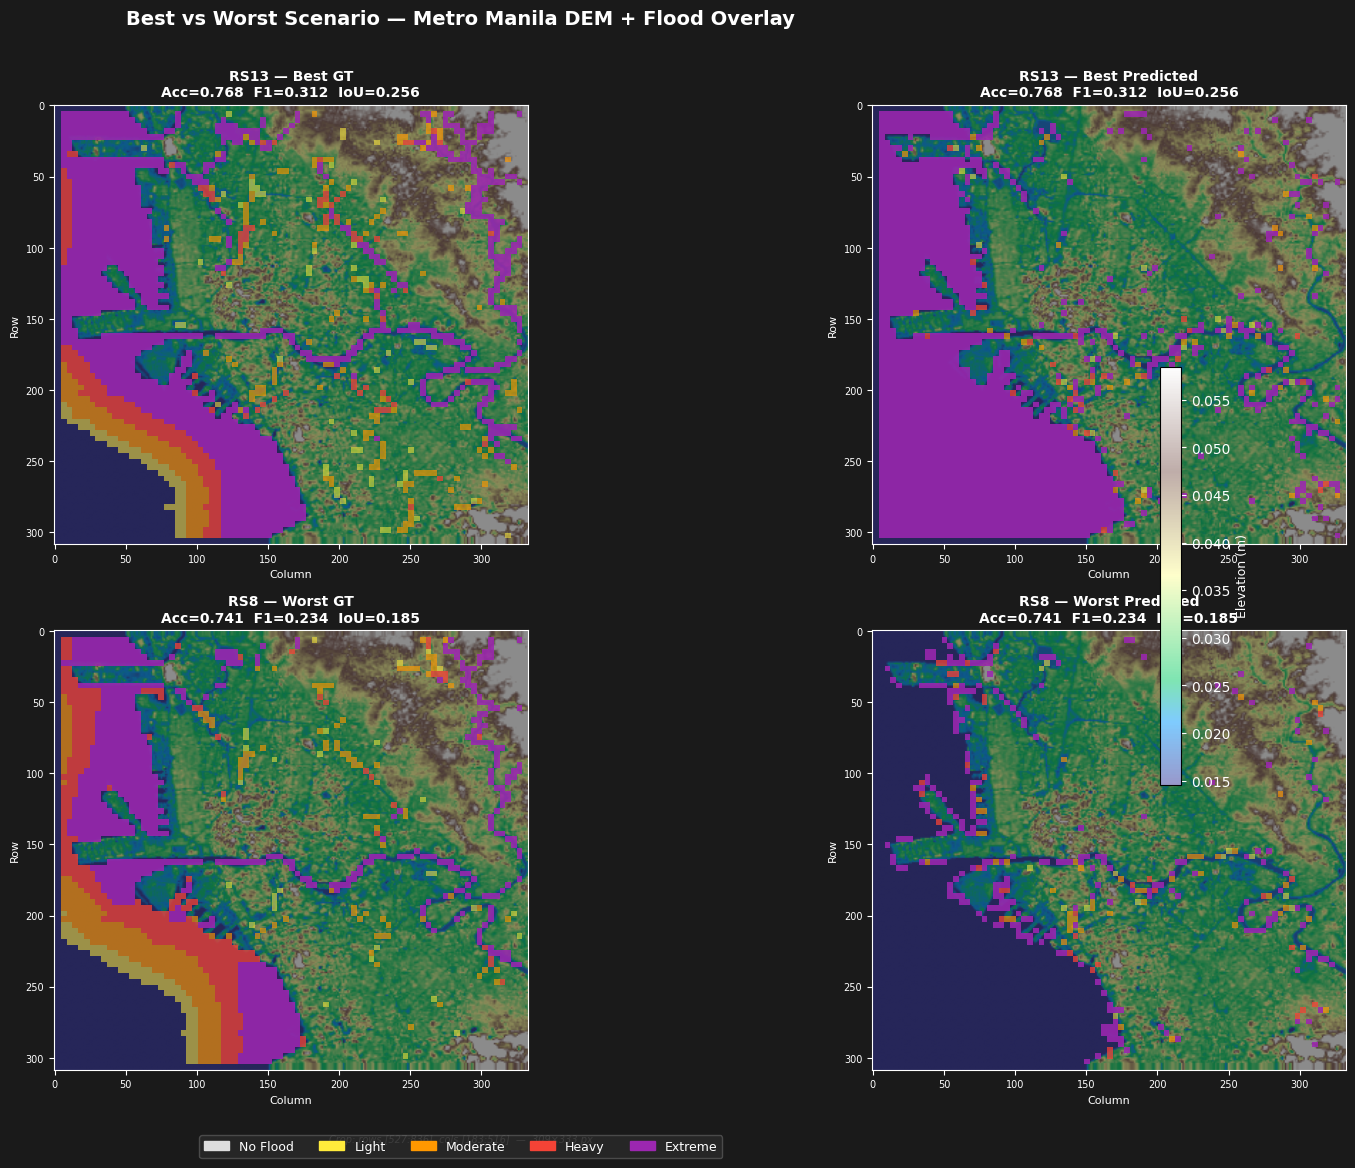

In [ ]:
fig_grid = plot_best_worst_dem(dem=dem_for_plot, results=eval_results, figsize=(18, 11))
fig_grid.savefig(OUTPUT_DIR / 'predictions' / 'eval_dem_best_worst_grid.png', dpi=150, bbox_inches='tight')

plt.show()